# 05 - Modelling 
## Objectives
The objective of this notebook is to predict the next-hour French day-ahead electricity price using market fundamentals and renewable generation features.

Because electricity prices exhibit strong temporal dependence, seasonality, and extreme scarcity events, the modelling approach emphasizes:

- Time-aware validation
- Leakage prevention
- Robust handling of non-linear relationships
- Separate evaluation of tail-price behavior 

## Data
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno
import pyarrow
sys.path.append("../src")
import style 
style.apply_style()
pd.set_option("display.max_columns", 50)

df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")

## Target

In [69]:
col_modelling = [
    "Day-ahead Price (EUR/MWh)",
    "Actual Total Load (MW)_load",
    "Day-ahead Total Load Forecast (MW)_load",
    "Day-ahead (MW)_wind_onshore",
    "Day-ahead (MW)_solar"
]

df = df_alls[col_modelling].copy()
df["Actual Total Load (MW)_load"] = df["Actual Total Load (MW)_load"].interpolate()
df["target_price"] = df["Day-ahead Price (EUR/MWh)"].shift(-1)

## Feature engineering
### Calendar features

In [70]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

In [71]:
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

### Lag features

In [72]:
df["price_lag_1"] = df["Day-ahead Price (EUR/MWh)"].shift(1)
df["price_lag_24"] = df["Day-ahead Price (EUR/MWh)"].shift(24)
df["price_lag168"] = df["Day-ahead Price (EUR/MWh)"].shift(168)

### Rolling statistics

In [73]:
df["price_roll_mean_24"] = (
    df["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()
)

df["price_roll_std_24"] = (
    df["Day-ahead Price (EUR/MWh)"].rolling(window = 24).std()
)

df.isna().sum()

Day-ahead Price (EUR/MWh)                    0
Actual Total Load (MW)_load                  0
Day-ahead Total Load Forecast (MW)_load      0
Day-ahead (MW)_wind_onshore                  0
Day-ahead (MW)_solar                         0
target_price                                 1
hour                                         0
dayofweek                                    0
month                                        0
is_weekend                                   0
hour_sin                                     0
hour_cos                                     0
month_sin                                    0
month_cos                                    0
price_lag_1                                  1
price_lag_24                                24
price_lag168                               168
price_roll_mean_24                          23
price_roll_std_24                           23
dtype: int64

In [74]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78743 entries, 2016-01-08 00:00:00+01:00 to 2024-12-31 22:00:00+01:00
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Day-ahead Price (EUR/MWh)                78743 non-null  float64
 1   Actual Total Load (MW)_load              78743 non-null  float64
 2   Day-ahead Total Load Forecast (MW)_load  78743 non-null  float64
 3   Day-ahead (MW)_wind_onshore              78743 non-null  float64
 4   Day-ahead (MW)_solar                     78743 non-null  float64
 5   target_price                             78743 non-null  float64
 6   hour                                     78743 non-null  int32  
 7   dayofweek                                78743 non-null  int32  
 8   month                                    78743 non-null  int32  
 9   is_weekend                               78743 non-null  int64  
 10 

### Renewable features

In [76]:
df["renewable_ratio"] = (
    df["Day-ahead (MW)_solar"] +  
    df["Day-ahead (MW)_wind_onshore"] 
)/df["Day-ahead Total Load Forecast (MW)_load"]

### Scarcity / stress indicators

In [77]:
df["residual_load"] = (df["Day-ahead Total Load Forecast (MW)_load"] - (
    df["Day-ahead (MW)_solar"] 
    + df["Day-ahead (MW)_wind_onshore"]
    ))

df["high_residual_load"] = (
    df["residual_load"] > df["residual_load"].quantile(0.05)
).astype(int)

In [78]:
features = [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek",
    "is_weekend",

    "price_lag_1",
    "price_lag_24",
    "price_lag168",
    "price_roll_mean_24",
    "price_roll_std_24",

    "Actual Total Load (MW)_load",
    "Day-ahead Total Load Forecast (MW)_load",

    "Day-ahead (MW)_wind_onshore",
    "Day-ahead (MW)_solar",

    "renewable_ratio",
    "residual_load",
    "high_residual_load"
]

## Train test split
Since 2022 introduced an unprecedented market volatility due to the energy crisis in Europe, we will split the dataset accordingly to ensure model robustness under regime shifts. 

The training set will be 2016-2020, validation set will be 2021. 2022 will be used for stress test. 2023-2024 will be used for recovery and generalization test.

In [79]:
df_2016_2020 = df[(df.index.year >= 2016) & (df.index.year <= 2020)].copy()
df_2021 = df[df.index.year == 2021].copy()
df_2022 = df[df.index.year == 2022].copy()
df_2023_2024 = df[(df.index.year >= 2023) & (df.index.year <= 2024)]

In [80]:
X_train = df_2016_2020[features]
y_train = df_2016_2020[["target_price"]]
X_val = df_2021[features]
y_val = df_2021[["target_price"]]
X_test = df_2022[features]
y_test = df_2022[["target_price"]]

## Time-series cross-validation

In [81]:
from sklearn.model_selection import TimeSeriesSplit

In [82]:
tscv = TimeSeriesSplit(n_splits = 5)

## Baseline models
### Persistence model

In [83]:
pred_naive = X_test["price_lag_1"]

### Previous day same hour

In [84]:
pred_24h = X_test["price_lag_24"]

## Gradient boosting modelling

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error 


model = LGBMRegressor(
    n_estimators = 300, 
    learning_rate = 0.05,
    max_depth = 6,
    num_leaves = 31,
    random_state = 42
)

model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [104]:
y_val_pred = model.predict(X_val)
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = root_mean_squared_error(y_val, y_val_pred)
print("Validation MAE", mae_val, "\n", "Validation RMSE", rmse_val)

Validation MAE 40.98736865939388 
 Validation RMSE 77.87454884207504


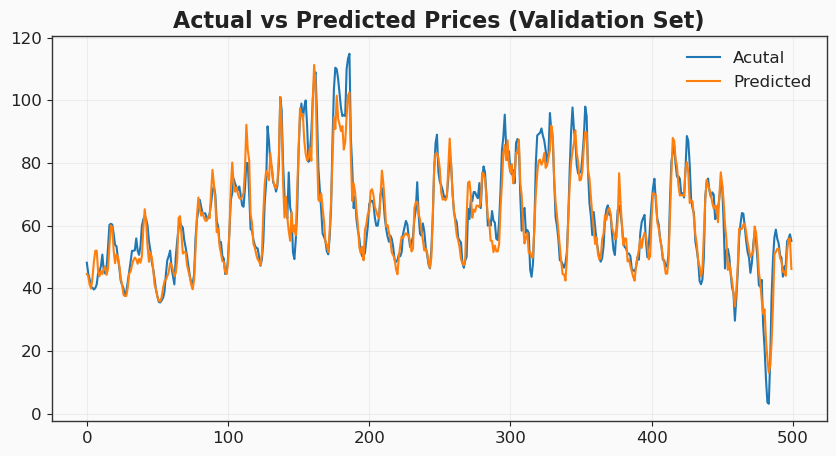

In [105]:
plt.figure()
plt.plot(y_val.iloc[:500].values,
         label = "Acutal")

plt.plot(y_val_pred[:500],
         label = "Predicted")

plt.legend()
plt.title("Actual vs Predicted Prices (Validation Set)")
plt.show()

In [ ]:

mae_naive = mean_absolute_error(y_test_pred, pred_naive)
mae_naive

206.44439527403134

In [ ]:
root_mean_squared_error(y_test_pred, pred_naive)

249.02770537252513

In [93]:
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(
    estimator = model,
    cv = tscv
)
clf.fit(X_train, y_train)

TypeError: GridSearchCV.__init__() missing 1 required positional argument: 'param_grid'